In [ ]:
!pip install adversarial-robustness-toolbox
!pip install art

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 606.3/606.3 kB 11.2 MB/s eta 0:00:00


In [ ]:
import warnings
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from keras.losses import CategoricalCrossentropy
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from art import config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
warnings.filterwarnings('ignore')
dataset_dir = ['/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Dataset/Manual/Preprocessed',
               '/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Dataset/Automated/Preprocessed']
image_data = []
image_labels = []

In [ ]:
def process_image(image_path):
    image = Image.open(image_path)
    image_array = np.array(image)
    image_array_flat = image_array.flatten()
    return image_array_flat

In [ ]:
def extract_label_from_filename(filename):
    name_parts = filename.split('_')
    class_info = name_parts[1].split('.')[0]
    if class_info == "UNKNOWN":
        label = -1  # Assign -1 for unknown labels
    else:
        letter = class_info[0]
        try:
            label = ord(letter.upper())
        except ValueError:
            label = -2 # Assign -2 if there is an error in the processing
    return label

In [ ]:
for directory in dataset_dir:
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if os.path.isdir(folder_path):
            for image_file in os.listdir(folder_path):
                if image_file.endswith(".png"):
                    image_path = os.path.join(folder_path, image_file)
                    img_data = process_image(image_path)
                    image_data.append(img_data)
                    label = extract_label_from_filename(image_file)
                    image_labels.append(label)

In [ ]:
image_data = np.array(image_data)
image_labels = np.array(image_labels)

In [ ]:
scaler = StandardScaler()
image_data = scaler.fit_transform(image_data)

In [ ]:
valid_indices = image_labels >= 0
image_data = image_data[valid_indices]
image_labels = image_labels[valid_indices]
label_encoder = LabelEncoder()
image_labels = label_encoder.fit_transform(image_labels)
print(label_encoder.classes_)

[65 68 69 70 71 72 73 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]


In [1]:
num_classes = len(np.unique(image_labels))
image_labels = to_categorical(image_labels, num_classes=num_classes)

NameError: name 'np' is not defined

In [ ]:
save_path = '/content/drive/MyDrive/CSCI4880 Group Project/Group Project/processed_dataset.npz'
np.savez(save_path, image_data=image_data, image_labels=image_labels)

In [ ]:
optimizer = Adam(learning_rate=0.0001)
model = Sequential()
model.add(Dense(2048, input_shape=(3750,), activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(1024, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(22, activation='softmax', kernel_regularizer=l2(0.001)))
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 2048)                │       7,682,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 22)                  │           5,654 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,442,006 (39.83 MB)

 Trainable params: 10,442,006 (39.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(image_data, image_labels, test_size=0.2, random_state=42, stratify=image_labels)
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_classes), y=y_train_classes)
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
model.fit(X_train, y_train, epochs=20, class_weight=class_weights_dict, validation_data=(X_test, y_test))

Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4176 - loss: 7.6441 - val_accuracy: 0.6016 - val_loss: 6.4785
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6403 - loss: 6.7245 - val_accuracy: 0.7556 - val_loss: 5.8400
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7857 - loss: 5.5870 - val_accuracy: 0.7201 - val_loss: 5.9351
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7710 - loss: 5.6062 - val_accuracy: 0.7632 - val_loss: 5.6189
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8397 - loss: 5.1500 - val_accuracy: 0.7481 - val_loss: 5.5668
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8103 - loss: 5.3234 - val_accuracy: 0.7933 - val_loss: 5.3429
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8345 - loss: 5.1054 - val_accuracy: 0.8001 - val_loss: 5.2328
Epoch 8/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8962 - loss: 4.6943 - val_accuracy: 0

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test_classes, y_pred_classes))

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Accuracy: 0.8555783709787816
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.83      0.81      0.82       177
           2       0.88      0.80      0.84        55
           3       0.60      0.55      0.57        22
           4       0.96      0.97      0.96       225
           5       1.00      0.50      0.67         2
           6       0.95      0.87      0.91        63
           7       0.00      0.00      0.00         1
           8       0.91      0.90      0.90       169
           9       0.88      0.89      0.89       211
          10       0.74      0.68      0.71        73
          11       0.60      0.55      0.57        11
          12       0.78      0.81      0.79        36
          13       0.87      0.95      0.91        21
          14       0.96      0.93      0.95       106
          15       0.71      0.62      0.67         8
        

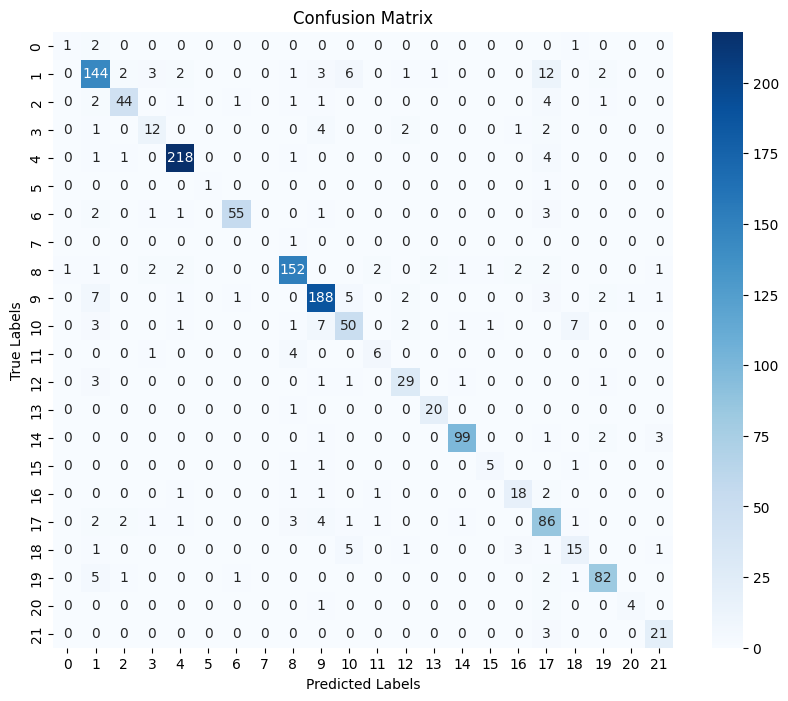

In [ ]:
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
file:model.save('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Garfunkle_Model.h5')

In [ ]:
file:model.save_weights('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Garfunkle.weights.h5')

In [ ]:
def pgd_attack(image, epsilon, alpha, num_iter, model, true_label):

    # Make a copy of the image to apply the attack
    perturbed_image = tf.identity(image)

    for i in range(num_iter):
        # Record the gradient of the loss with respect to the image
        with tf.GradientTape() as tape:
            tape.watch(perturbed_image)
            prediction = model(perturbed_image)
            loss = tf.keras.losses.sparse_categorical_crossentropy(true_label, prediction)

        # Calculate the gradient of the loss with respect to the image
        gradient = tape.gradient(loss, perturbed_image)

        # Apply the FGSM step (sign of the gradient multiplied by step size alpha)
        signed_grad = tf.sign(gradient)
        perturbed_image = perturbed_image + alpha * signed_grad

        # Project the image back to the epsilon ball and maintain valid pixel range [0, 1]
        perturbed_image = tf.clip_by_value(perturbed_image, image - epsilon, image + epsilon)
        perturbed_image = tf.clip_by_value(perturbed_image, 0, 1)

    return perturbed_image

In [ ]:
# Set the epsilon, alpha (step size), and number of iterations for the attack
epsilon = 0.1
alpha = 0.01  # The step size for each iteration
num_iter = 40  # Number of iterations

# Get a batch of images and labels from the test generator
images, labels = next(iter(testGenerator))

# Convert images to a tensor and enable gradient tracking
images_tensor = tf.convert_to_tensor(images)
images_tensor = tf.Variable(images_tensor)

# Generate adversarial examples using PGD
perturbed_images = pgd_attack(images_tensor, epsilon, alpha, num_iter, model, labels)

# Convert perturbed images back to numpy for evaluation
perturbed_images_np = perturbed_images.numpy()


NameError: name 'testGenerator' is not defined